# 1.052/1.121/2.174J: Advancing Mechanics and Materials via Machine Learning  

### Simple neural network to model nonlinear beam deformation [F, t, L] --> displacement

Generates a synthetic dataset, then trains a regression model

### How the synthetic dataset was generated

To illustrate learning displacement from force and geometry, we construct a synthetic dataset inspired by classical beam mechanics, with added nonlinearity and noise. For each sample, we randomly drew a force magnitude \(F \in [0,10]\), a beam thickness \(t \in [0.5,2.0]\), and a beam length \(L \in [1,5]\). The displacement was generated using a beam-like scaling based on Euler–Bernoulli theory, where deflection grows linearly with force, cubically with length, and inversely with the cube of thickness (\(u \sim F L^3 / t^3\)). 

To make the problem more realistic and challenging, we introduced nonlinear geometric stiffening at higher loads and longer lengths, which reduces the incremental compliance, as well as a mild additional nonlinearity that depends on the displacement magnitude. Finally, we added heteroskedastic Gaussian noise that increases with force, mimicking experimental uncertainty. The resulting dataset captures key physical trends (force and geometry dependence) while remaining nonlinear and noisy, making it suitable for comparing purely data-driven regression models with physics-informed approaches.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

# Create a synthetic dataset (beam-like, nonlinear)
np.random.seed(42)
torch.manual_seed(42)

# Number of datapoints
N = 20000

# Force: scalar in [0, 10]
F = np.random.uniform(0.0, 10.0, size=(N, 1))

# Geometry: thickness t and length L
t = np.random.uniform(0.5, 2.0, size=(N, 1))   # thickness
L = np.random.uniform(1.0, 5.0, size=(N, 1))   # length

geom = np.hstack([t, L])

# -------------------------
# Beam-inspired "ground truth"
# -------------------------
# Rectangular cross-section with fixed width b = 1:
# I = b*t^3/12  -> compliance ~ 1/t^3
b = 1.0
I = b * t**3 / 12.0

# Effective modulus  
E = 10.0

# Linear Euler–Bernoulli-like deflection scaling (up to a constant)
u_lin = F * (L**3) / (E * I)   # ~ F L^3 / (E t^3)

# Nonlinear geometric stiffening: reduces deflection at larger loads/longer beams
# u = u_lin / (1 + alpha*(F/F0)^2*(L/L0)^2)
alpha = 0.20
F0, L0 = 5.0, 3.0
stiffen = 1.0 + alpha * (F / F0)**2 * (L / L0)**2
true_disp = u_lin / stiffen

# Mild additional nonlinearity (kept monotone, small effect)
# e.g., slight softening with displacement magnitude
beta = 0.05
true_disp = true_disp * (1.0 + beta * np.tanh(true_disp / (np.percentile(true_disp, 90) + 1e-8)))

# Heteroskedastic noise: slightly larger noise at higher forces
sigma = 0.03 * np.std(true_disp)
noise = np.random.normal(0.0, sigma, size=true_disp.shape) * (1.0 + 0.15 * (F / 10.0))
disp = true_disp + noise

# Assemble features/targets
X = np.hstack([F, geom])  # [F, t, L]
y = disp

# Convert to torch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Dataset class
class ForceGeomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = ForceGeomDataset(X_tensor, y_tensor)

# Train-test split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(
    dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproducible split
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [27]:
X_tensor.shape, y_tensor.shape

(torch.Size([20000, 3]), torch.Size([20000, 1]))

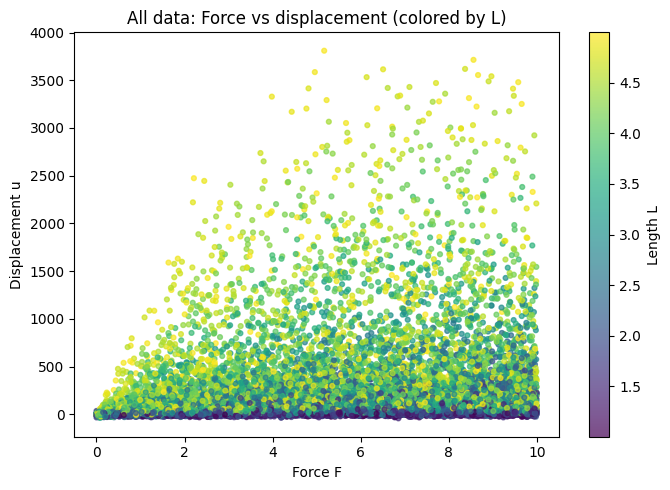

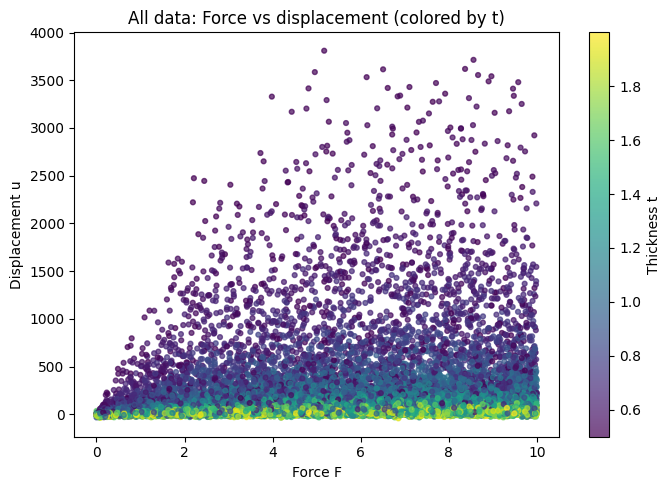

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# X is [F, t, L], y is disp
F_all = X[:, 0]
t_all = X[:, 1]
L_all = X[:, 2]
u_all = y[:, 0]

plt.figure(figsize=(7,5))
sc = plt.scatter(F_all, u_all, c=L_all, s=12, alpha=0.7)
plt.colorbar(sc, label="Length L")
plt.xlabel("Force F")
plt.ylabel("Displacement u")
plt.title("All data: Force vs displacement (colored by L)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sc = plt.scatter(F_all, u_all, c=t_all, s=12, alpha=0.7)
plt.colorbar(sc, label="Thickness t")
plt.xlabel("Force F")
plt.ylabel("Displacement u")
plt.title("All data: Force vs displacement (colored by t)")
plt.tight_layout()
plt.show()


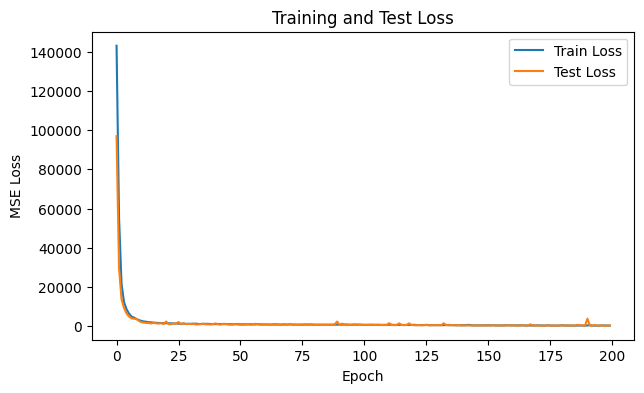

In [29]:
# Define a neural network
class MLP(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

model = MLP()

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 4. Training loop
num_epochs = 200
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        preds = model(batch_X)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    train_loss = running_loss / train_size
    train_losses.append(train_loss)

    # Evaluate on test
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            preds = model(batch_X)
            loss = criterion(preds, batch_y)
            running_loss += loss.item() * batch_X.size(0)
    test_loss = running_loss / test_size
    test_losses.append(test_loss)

# Plot training and test loss curves
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()



Using slice around t0=1.252, L0=3.000 -> 84 points


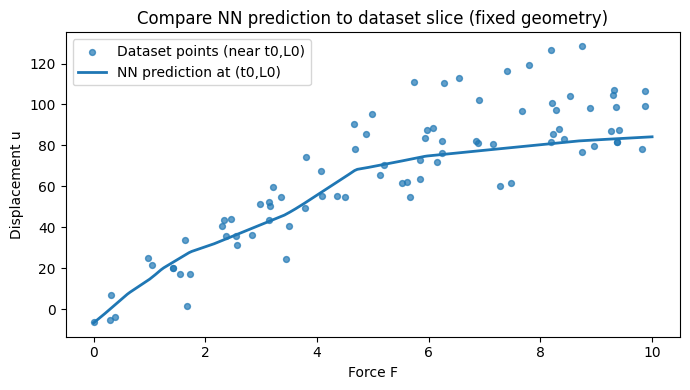

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Use your existing arrays:
# X = [F, t, L], y = displacement
F_all = X[:,0]
t_all = X[:,1]
L_all = X[:,2]
u_all = y[:,0] if y.ndim == 2 else y

# Choose a target geometry (e.g. median)
t0 = float(np.median(t_all))
L0 = float(np.median(L_all))

# Select nearby points in geometry space (tolerance bands)
t_tol = 0.05   
L_tol = 0.10   
mask = (np.abs(t_all - t0) < t_tol) & (np.abs(L_all - L0) < L_tol)

print(f"Using slice around t0={t0:.3f}, L0={L0:.3f} -> {mask.sum()} points")

# Scatter the actual dataset points for that geometry slice
plt.figure(figsize=(7,4))
plt.scatter(F_all[mask], u_all[mask], s=18, alpha=0.7, label="Dataset points (near t0,L0)")

# Overlay NN prediction curve at exactly (t0, L0)
F_sweep = np.linspace(0, 10, 200).reshape(-1,1).astype(np.float32)
t_sweep = np.full_like(F_sweep, t0, dtype=np.float32)
L_sweep = np.full_like(F_sweep, L0, dtype=np.float32)
X_sweep = np.hstack([F_sweep, t_sweep, L_sweep]).astype(np.float32)

with torch.no_grad():
    pred_sweep = model(torch.tensor(X_sweep, dtype=torch.float32)).cpu().numpy().ravel()

plt.plot(F_sweep.ravel(), pred_sweep, linewidth=2, label="NN prediction at (t0,L0)")

plt.xlabel("Force F")
plt.ylabel("Displacement u")
plt.title("Compare NN prediction to dataset slice (fixed geometry)")
plt.legend()
plt.tight_layout()
plt.show()

